# 🔬 Interactive Tutorial: Basics of Uproot, Awkward Array, and Vector

Welcome to the world of **Columnar Analysis** in High-Energy Physics (HEP)! This notebook introduces the core toolkit used to analyze terabytes of collision data efficiently without relying on a full C++ ROOT installation.

### 🎯 Learning Objectives
1. **Uproot**: Open ROOT files and extract data columns as arrays.
2. **Awkward Array**: Manipulate "jagged" or ragged data (where events have different numbers of particles).
3. **Vector**: Perform 2D, 3D, and Lorentz vector kinematics seamlessly over arrays.

## 🛠️ Step 0: Setup and Installation
Let's install the packages first. Run the cell below to ensure you have everything needed.

In [ ]:
!pip install uproot awkward vector matplotlib numpy

## 📂 Module 1: Uproot (Accessing ROOT Data)
ROOT files store data in a tree structure (`TTree`), where branches (`TBranch`) represent variables or columns.

Let's import `uproot` and see how to open a remote open-data file.

In [3]:
import uproot

# Open a public CMS NanoAOD open-data file
#url = "https://xrootd-local.fnal.gov/xroot/cms/store/user/cmsopen/AOD2NanoAODOutreachTool/v1.1.1/Phase2016/MC/TTJets_Tunnel.root"

#A. Print All Branch Names (Like edmDumpEventContent short mode)
# Returns a list of all branch names in the Events tree
#print(tree.keys())
# Open the file context
with uproot.open("sample.root") as file:
    print("File contents:", file.keys())
    
    # Access the 'Events' tree
    tree = file["Events"]
    print(f"\nNumber of events in tree: {tree.num_entries}")


#B. Print Branch Names with C++ Data Types (Exact edmDumpEventContent replica)
#To view both the branch name and its underlying C++ type/class structure:
# Prints: 'Branch_Name': 'Data_Type'
#for name, typename in tree.typenames().items():
#    print(f"{name:50s} : {typename}")

#C. Filter for Specific Collections (e.g., Electron branches only)
#If you only want to inspect branches belonging to a specific physics object:
# Search for branches matching a pattern (e.g., all Electron branches)
#electron_branches = tree.keys(filter_name="Electron_*")
#print(electron_branches)

#D. Print branch name and type for a specific object collection
#for name, typename in tree.typenames(filter_name="Electron_*").items():
#    print(f"{name:30s} -> {typename}")
#print(f"Total branches in tree: {len(tree.keys())}\n")


File contents: ['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']

Number of events in tree: 26394


### 🔍 Inspecting Branches
Let's look at available fields for electrons.

In [8]:
with uproot.open("sample.root") as file:
    tree = file["Events"]
    # Filter and display branches starting with 'Electron_'
    electron_branches = [k for k in tree.keys() if k.startswith("Electron_")]
    print("Available electron columns:", electron_branches[:6])

print()
#C. Filter for Specific Collections (e.g., Electron branches only)
#If you only want to inspect branches belonging to a specific physics object:
# Search for branches matching a pattern (e.g., all Electron branches)
electron_branches = tree.keys(filter_name="Electron_*")
print(electron_branches[:6])
print()
print(electron_branches)

Available electron columns: ['Electron_dEscaleDown', 'Electron_dEscaleUp', 'Electron_dEsigmaDown', 'Electron_dEsigmaUp', 'Electron_deltaEtaSC', 'Electron_dr03EcalRecHitSumEt']

['Electron_dEscaleDown', 'Electron_dEscaleUp', 'Electron_dEsigmaDown', 'Electron_dEsigmaUp', 'Electron_deltaEtaSC', 'Electron_dr03EcalRecHitSumEt']

['Electron_dEscaleDown', 'Electron_dEscaleUp', 'Electron_dEsigmaDown', 'Electron_dEsigmaUp', 'Electron_deltaEtaSC', 'Electron_dr03EcalRecHitSumEt', 'Electron_dr03HcalDepth1TowerSumEt', 'Electron_dr03TkSumPt', 'Electron_dr03TkSumPtHEEP', 'Electron_dxy', 'Electron_dxyErr', 'Electron_dz', 'Electron_dzErr', 'Electron_eCorr', 'Electron_eInvMinusPInv', 'Electron_energyErr', 'Electron_eta', 'Electron_hoe', 'Electron_ip3d', 'Electron_jetPtRelv2', 'Electron_jetRelIso', 'Electron_mass', 'Electron_miniPFRelIso_all', 'Electron_miniPFRelIso_chg', 'Electron_mvaFall17V2Iso', 'Electron_mvaFall17V2noIso', 'Electron_pfRelIso03_all', 'Electron_pfRelIso03_chg', 'Electron_phi', 'Electro

### 📥 Reading Data into Arrays
Instead of reading the whole file, we selectively read only the columns we need to maximize speed.

In [17]:
with uproot.open("sample.root") as file:
    tree = file["Events"]
    # Extract specific electron fields as an Awkward Array
    arrays = tree.arrays(["Electron_pt", "Electron_eta", "Electron_phi", "Electron_mass"])

print("Loaded arrays type:", type(arrays))
print("Preview of Electron_pt:", arrays["Electron_pt"])


Loaded arrays type: <class 'awkward.highlevel.Array'>
Preview of Electron_pt: [[70.9, 28.1, 15.4], [43.7], [51.6, 37.6], ..., [], [], [31.7, 18.4, 14.5]]


--- 
## 🧩 Module 2: Awkward Array (Handling Ragged Data)
In HEP, one collision event might produce 0 electrons, another might produce 3. Standard NumPy arrays cannot handle rows of varying lengths without awkward padding. `awkward` (imported as `ak`) handles this "jaggedness" natively and efficiently.

In [18]:
import awkward as ak

pt = arrays["Electron_pt"]
print("pt is", type(pt))
print("First 5 events of Electron pT:")
for i in range(5):
    print(f"Event {i}: {pt[i]}")

print(f"\nArray type structure: {ak.type(pt)}")

pt is <class 'awkward.highlevel.Array'>
First 5 events of Electron pT:
Event 0: [70.9, 28.1, 15.4]
Event 1: [43.7]
Event 2: [51.6, 37.6]
Event 3: [43.8, 6.45, 5.84]
Event 4: [77.6, 31.1]

Array type structure: 26394 * var * float32


### 📈 Basic Operations on Jagged Arrays
You can run operations directly over the array structure without loops!

In [12]:
# Find how many electrons are in each event
counts = ak.num(pt)
print("Electrons per event (first 5 events):", counts[:5])
print("pt", pt)
# Apply a scalar multiplier (e.g., converting GeV to MeV)
pt_mev = pt * 1000
print("pT in MeV (first event):", pt_mev[0])

Electrons per event (first 5 events): [3, 1, 2, 3, 2]
pt [[70.9, 28.1, 15.4], [43.7], [51.6, 37.6], ..., [], [], [31.7, 18.4, 14.5]]
pT in MeV (first event): [7.09e+04, 2.81e+04, 1.54e+04]


### ✂️ Masking and Filtering (Boolean Indexing)
Let's select only electrons with a transverse momentum $p_T > 20$ GeV.

In [13]:
# Create a boolean mask matching the shape of our jagged array
kinematic_mask = pt > 20
print("Mask for first 3 events:", kinematic_mask[:3])

# Apply the mask
good_electrons = pt[kinematic_mask]
print("Filtered pT for first 3 events:", good_electrons[:3])

Mask for first 3 events: [[True, True, False], [True], [True, True]]
Filtered pT for first 3 events: [[70.9, 28.1], [43.7], [51.6, 37.6]]


--- 
## 🚀 Module 3: Vector (Kinematics Made Easy)
Calculating invariant mass or deltaR values traditionally requires verbose math formulas. The `vector` package lets you treat arrays as geometric vectors.

In [19]:
import vector
# Register vector's properties inside Awkward array calculations
vector.register_awkward()

# Package our separate branches into a unified 4-momentum Lorentz coordinate system object
electrons = ak.zip(
    {
        "pt": arrays["Electron_pt"],
        "eta": arrays["Electron_eta"],
        "phi": arrays["Electron_phi"],
        "mass": arrays["Electron_mass"],
    },
    with_name="Momentum4D",
)

print("Electron structures packaged as Momentum4D.")
print("First event's coordinate metadata:", electrons[0])

Electron structures packaged as Momentum4D.
First event's coordinate metadata: [{pt: 70.9, eta: 2.01, phi: 0.392, mass: -0.0576}, {...}, {pt: 15.4, ...}]


### 🔄 Automatic Coordinate Transformations
Even though we initialized with `pt`, `eta`, `phi`, and `mass`, `vector` can calculate cartesian components on-the-fly without manual conversion equations!

In [20]:
print("X-momentum (px) for first event:", electrons.px[0])
print("Energy (E) for first event:", electrons.energy[0])

X-momentum (px) for first event: [65.5, -5.04, -14.7]
Energy (E) for first event: [270, 30, 20.9]


--- 
## 🧪 Challenge: Reconstruct the Dielectron Invariant Mass Peak!
Let's put everything together to build a mini-analysis workflow. We will select events with exactly two electrons, calculate their invariant mass, and plot the distribution.

In [21]:
import matplotlib.pyplot as plt

# 1. Filter out events that do not contain at least 2 electrons
has_two_electrons = ak.num(electrons) >= 2
dielectron_events = electrons[has_two_electrons]

# 2. Take the first two electrons from each event
lep1 = dielectron_events[:, 0]
lep2 = dielectron_events[:, 1]

# 3. Add them together using Vector math to construct the parent particle system
parent_system = lep1 + lep2

# 4. Calculate the invariant mass directly!
invariant_mass = parent_system.mass

print(f"Calculated invariant mass for {len(invariant_mass)} candidates.")

Calculated invariant mass for 10026 candidates.


### 📊 Plotting the Peak

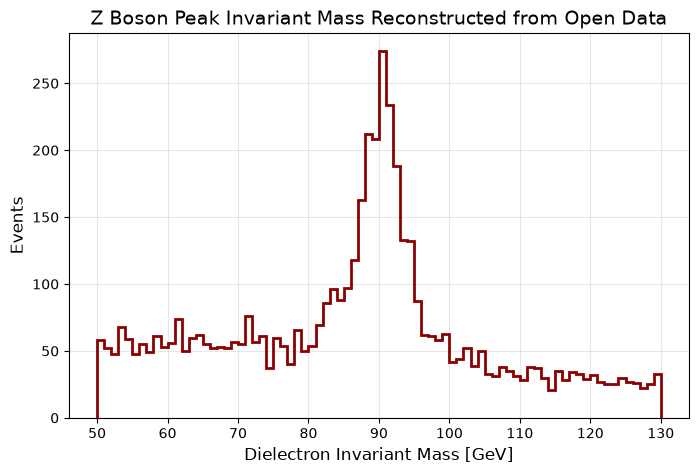

In [22]:
plt.figure(figsize=(8, 5))
# Flatten the array to numpy for standard matplotlib plotting
plt.hist(ak.to_numpy(invariant_mass), bins=80, range=(50, 130), histtype='step', color='darkred', lw=2)

plt.xlabel("Dielectron Invariant Mass [GeV]", fontsize=12)
plt.ylabel("Events", fontsize=12)
plt.title("Z Boson Peak Invariant Mass Reconstructed from Open Data", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

🎉 **Congratulations!** You have completed the basic intro tutorial to Uproot, Awkward Arrays, and Vector kinematics! You are ready to handle columnar datasets in high-energy physics analysis like a pro.